In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
df = pd.read_csv(r"C:\financial-forecasting-budget-variance\data\financial_data.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date")
df.head()

,revenue,expenses,budgeted_expenses
date,,,
2021-01-01,120000,78000,75000
2021-04-01,135000,82000,80000
2021-07-01,142000,86000,83000
2021-10-01,165000,97000,90000
2022-01-01,150000,88000,85000


<function matplotlib.pyplot.show(close=None, block=None)>

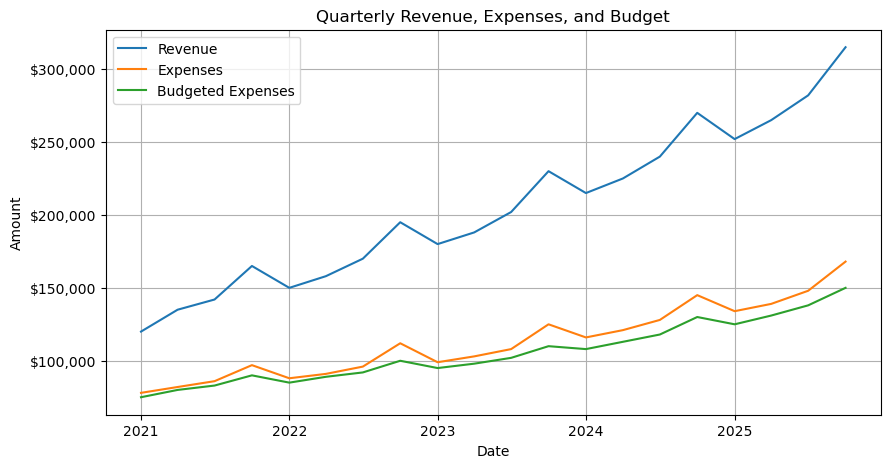

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(df.index,df["revenue"],label="Revenue")
plt.plot(df.index,df["expenses"],label="Expenses")
plt.plot(df.index,df["budgeted_expenses"],label="Budgeted Expenses")
plt.title("Quarterly Revenue, Expenses, and Budget")
plt.xlabel("Date")
plt.ylabel("Amount")
plt.legend()
plt.grid(True)
fmt = '${x:,.0f}'#tells python to put a dollar sign at the start ,x represents the value on the x axis, ,: tells python to add comma as a thousands seperator.
tick = mtick.StrMethodFormatter(fmt)#"Creates a Formatter object"
plt.gca().yaxis.set_major_formatter(tick)#Get Current Axes"
plt.show

In [12]:
df["expense_variance"] = df["expenses"] - df["budgeted_expenses"]
df["expense_variance_pct"] = (df["expense_variance"] / df["budgeted_expenses"]) * 100
df["variance_flag"] = df["expense_variance_pct"].apply(lambda x:"Over Budget" if x>10 else "Within Budget")
df


,revenue,expenses,budgeted_expenses,expense_variance,expense_variance_pct,variance_flag
date,,,,,,
2021-01-01,120000,78000,75000,3000,4.000000,Within Budget
2021-04-01,135000,82000,80000,2000,2.500000,Within Budget
2021-07-01,142000,86000,83000,3000,3.614458,Within Budget
2021-10-01,165000,97000,90000,7000,7.777778,Within Budget
2022-01-01,150000,88000,85000,3000,3.529412,Within Budget
2022-04-01,158000,91000,89000,2000,2.247191,Within Budget
2022-07-01,170000,96000,92000,4000,4.347826,Within Budget
2022-10-01,195000,112000,100000,12000,12.000000,Over Budget
2023-01-01,180000,99000,95000,4000,4.210526,Within Budget


In [15]:
from statsmodels.tsa.arima.model import ARIMA #importing time series analysis package from statsmodel library. ARIMA- autoregressive integrated moving average.
revenue_data = df["revenue"]
model = ARIMA(revenue_data, order=(1,1,1))
model_fit = model.fit()
print(model_fit.summary())


                               SARIMAX Results                                
Dep. Variable:                revenue   No. Observations:                   20
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -210.510
Date:                Fri, 08 May 2026   AIC                            427.019
Time:                        17:44:20   BIC                            429.853
Sample:                    01-01-2021   HQIC                           427.499
                         - 10-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0000      0.004    258.535      0.000       0.992       1.008
ma.L1         -0.9993      0.473     -2.111      0.035      -1.927      -0.072
sigma2      2.346e+08   2.02e-09   1.16e+17      0.0

c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)


In [16]:
forecast = model_fit.forecast(steps=4)
print(forecast)

2026-01-01    324880.278189
2026-04-01    334760.528553
2026-07-01    344640.751092
2026-10-01    354520.945807
Freq: QS-OCT, Name: predicted_mean, dtype: float64


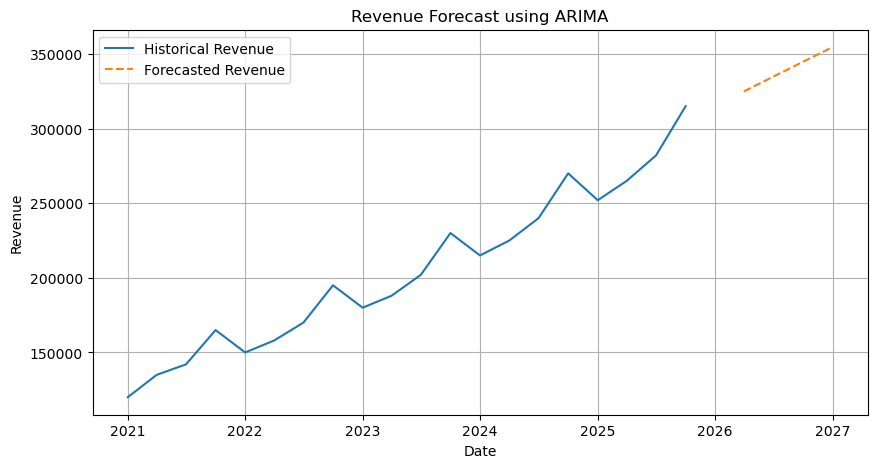

In [19]:
plt.figure(figsize=(10,5))
plt.plot(df.index, revenue_data, label = "Historical Revenue")
future_dates = pd.date_range(start = df.index[-1], periods=5, freq='Q')[1:]
plt.plot(future_dates,forecast,label="Forecasted Revenue",linestyle = "dashed")
plt.title("Revenue Forecast using ARIMA")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.grid(True)
plt.show()

In [18]:
# Convert forecast into dataframe
forecast_df = pd.DataFrame({
    "date": future_dates,
    "forecasted_revenue": forecast
})

# Save forecast results
forecast_df.to_csv(
    "../outputs/revenue_forecast.csv",
    index=False
)

forecast_df

,date,forecasted_revenue
2026-01-01,2026-03-31,324880.278189
2026-04-01,2026-06-30,334760.528553
2026-07-01,2026-09-30,344640.751092
2026-10-01,2026-12-31,354520.945807
